In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

### Простое экспоненциальное сглаживание

In [2]:
np.random.seed(42)
dates = pd.date_range(start="2022-01-01", periods=100, freq="D")
sales = 200 + np.arange(100)*0.5 + np.random.normal(scale=5, size=100)
df = pd.DataFrame({"sales": sales}, index=dates)

In [3]:
model = SimpleExpSmoothing(df["sales"], initialization_method="heuristic").fit(smoothing_level=0.3, optimized=False)
df["SES"] = model.fittedvalues
forecast = model.forecast(14)

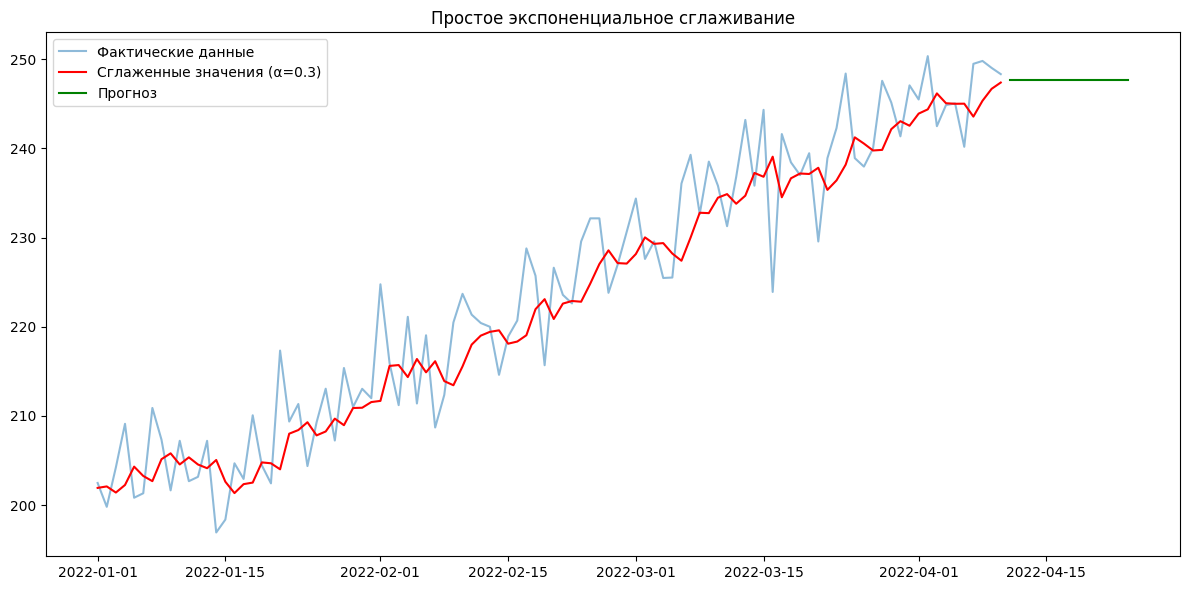

In [4]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["sales"], label="Фактические данные", alpha=0.5)
plt.plot(df.index, df["SES"], label="Сглаженные значения (α=0.3)", color="red")
plt.plot(pd.date_range(df.index[-1]+pd.Timedelta(days=1), periods=14, freq="D"), forecast, label="Прогноз", color="green")
plt.legend()
plt.title("Простое экспоненциальное сглаживание")
plt.tight_layout()
plt.show()

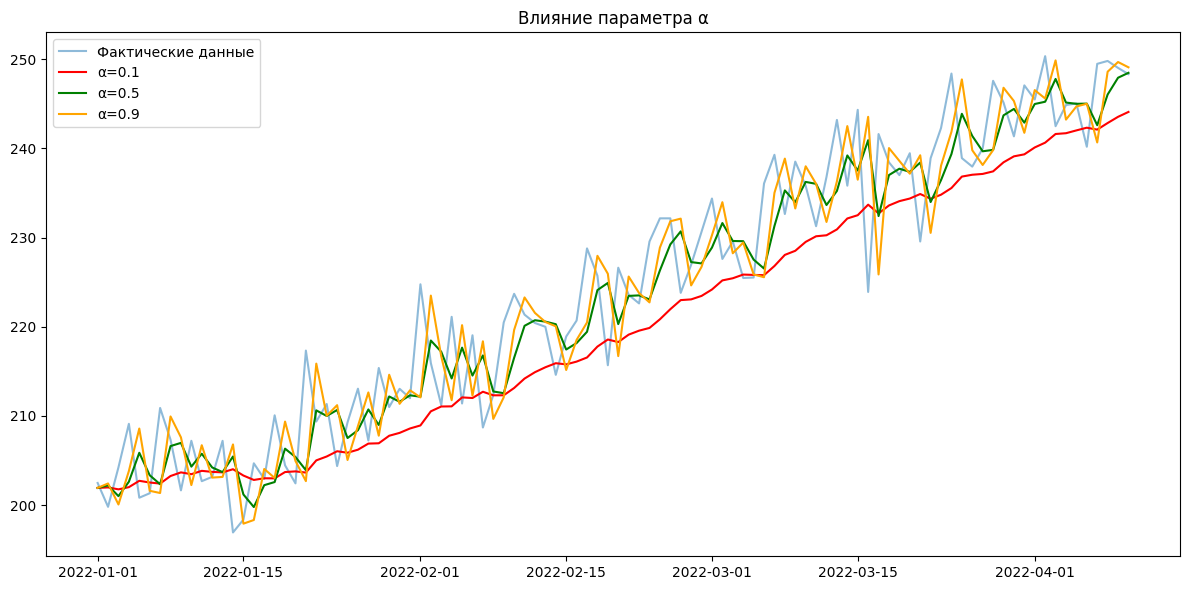

In [5]:
for alpha in [0.1, 0.5, 0.9]:
	model = SimpleExpSmoothing(df["sales"], initialization_method="heuristic").fit(smoothing_level=alpha, optimized=False)
	df[f"SES_{alpha}"] = model.fittedvalues
 
plt.figure(figsize=(12,6))
plt.plot(df.index, df["sales"], label="Фактические данные", alpha=0.5)
plt.plot(df.index, df["SES_0.1"], label="α=0.1", color="red")
plt.plot(df.index, df["SES_0.5"], label="α=0.5", color="green")
plt.plot(df.index, df["SES_0.9"], label="α=0.9", color="orange")
plt.legend()
plt.title("Влияние параметра α")
plt.tight_layout()
plt.show()

### Модель Хольта, учитавающая тренд

In [7]:
# Данные: рост + шум
np.random.seed(42)
dates = pd.date_range(start="2022-01-01", periods=100, freq="D")
sales = 100 + np.arange(100)*2 + np.random.normal(scale=10, size=100)
df = pd.DataFrame({"sales": sales}, index=dates)

In [8]:
# Модель Хольта
holt = ExponentialSmoothing(df["sales"], trend="add", seasonal=None, initialization_method="estimated").fit()
df["Holt"] = holt.fittedvalues
forecast = holt.forecast(14)

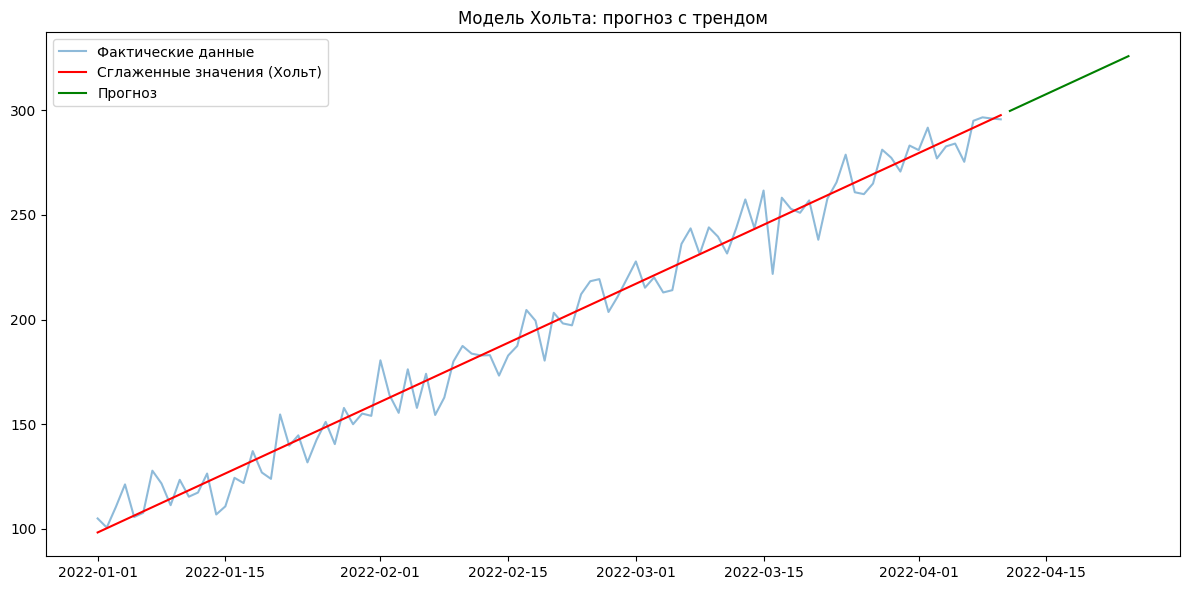

In [9]:
# Визуализация
plt.figure(figsize=(12,6))
plt.plot(df.index, df["sales"], label="Фактические данные", alpha=0.5)
plt.plot(df.index, df["Holt"], label="Сглаженные значения (Хольт)", color="red")
plt.plot(pd.date_range(df.index[-1]+pd.Timedelta(days=1), periods=14, freq="D"), forecast, label="Прогноз", color="green")
plt.legend()
plt.title("Модель Хольта: прогноз с трендом")
plt.tight_layout()
plt.show()

### Модель Хольта-Уинтерса, учитывающая тренд и сезонность

In [11]:
# Генерация данных: тренд + сезонность + шум
np.random.seed(42)
dates = pd.date_range(start="2020-01-01", periods=3*12, freq="ME")
trend = np.linspace(50, 100, 36)  # плавный рост
seasonal = 10*np.sin(2*np.pi*dates.month/12)  # годовая сезонность
noise = np.random.normal(scale=3, size=36)
sales = trend + seasonal + noise
df = pd.DataFrame({"sales": sales}, index=dates)

In [12]:
# Модель Хольта -- Уинтерса
hw = ExponentialSmoothing(
	df["sales"],
	trend="add",
	seasonal="add",
	seasonal_periods=12,
	initialization_method="estimated"
).fit()
 
df["HW"] = hw.fittedvalues
forecast = hw.forecast(12)

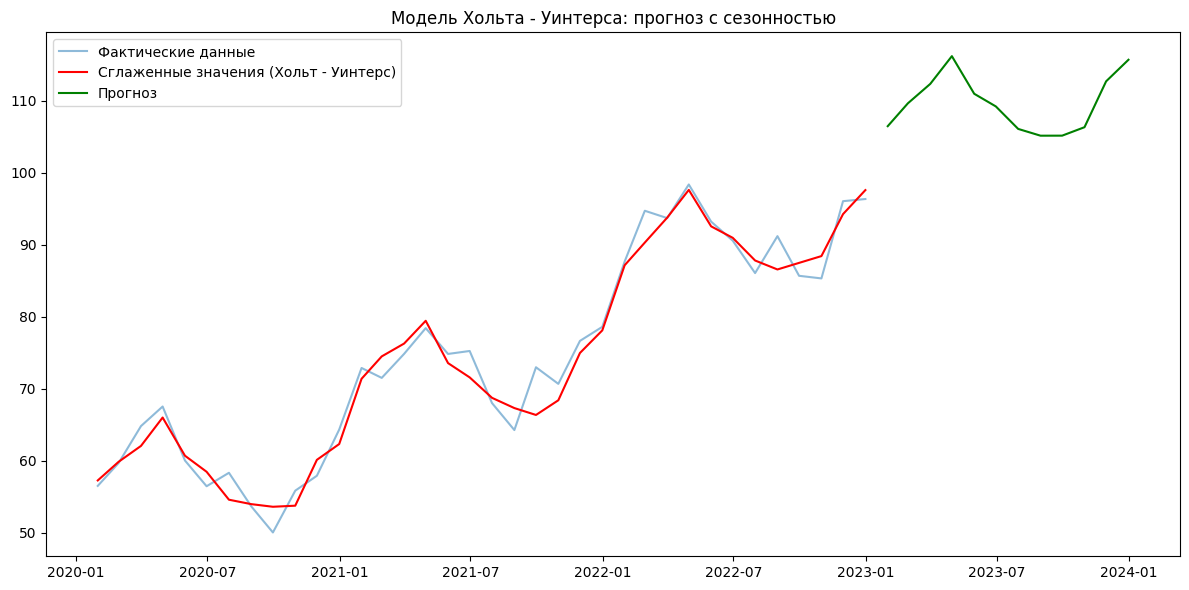

In [16]:
# Визуализация
plt.figure(figsize=(12,6))
plt.plot(df.index, df["sales"], label="Фактические данные", alpha=0.5)
plt.plot(df.index, df["HW"], label="Сглаженные значения (Хольт - Уинтерс)", color="red")
plt.plot(pd.date_range(df.index[-1]+pd.offsets.MonthEnd(), periods=12, freq="ME"), forecast, label="Прогноз", color="green")
plt.legend()
plt.title("Модель Хольта - Уинтерса: прогноз с сезонностью")
plt.tight_layout()
plt.show()

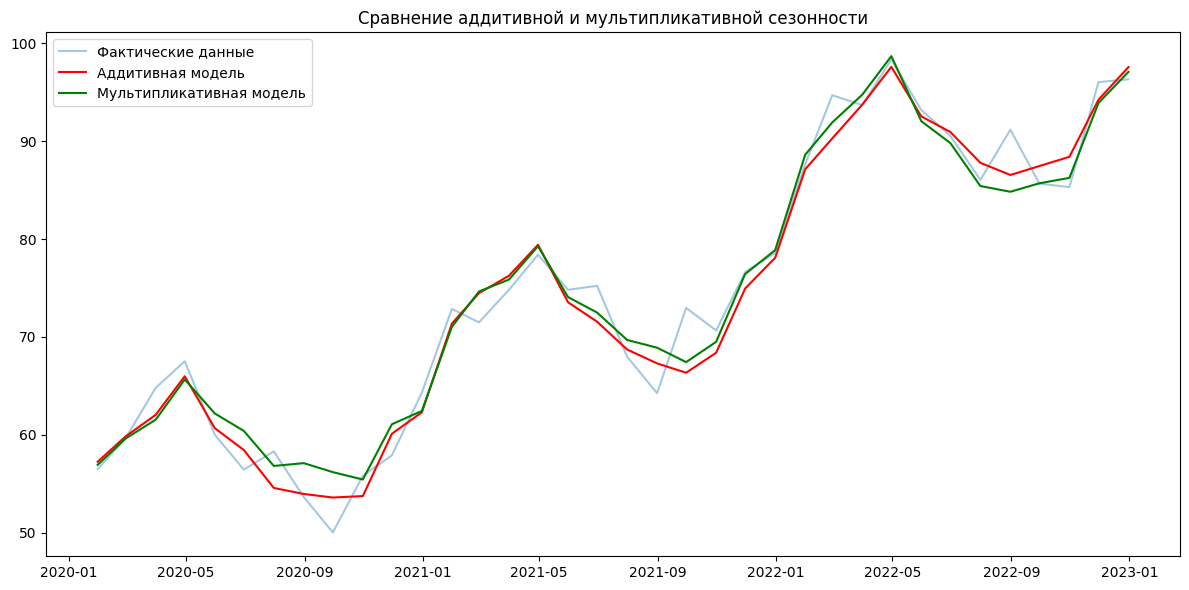

In [17]:
# Аддитивная модель
hw_add = ExponentialSmoothing(
	df["sales"], trend="add", seasonal="add", seasonal_periods=12
).fit()
 
# Мультипликативная модель
hw_mul = ExponentialSmoothing(
	df["sales"], trend="add", seasonal="mul", seasonal_periods=12
).fit()
 
plt.figure(figsize=(12,6))
plt.plot(df.index, df["sales"], label="Фактические данные", alpha=0.4)
plt.plot(hw_add.fittedvalues, label="Аддитивная модель", color="red")
plt.plot(hw_mul.fittedvalues, label="Мультипликативная модель", color="green")
plt.legend()
plt.title("Сравнение аддитивной и мультипликативной сезонности")
plt.tight_layout()
plt.show()

### Проверка различных коэффициентов уровня ($\alpha$), тренда ($\beta$) и сезонности ($\gamma$)

In [19]:
# Данные: тренд + сезонность + шум
np.random.seed(42)
dates = pd.date_range(start="2020-01-01", periods=48, freq="ME")
trend = np.linspace(50, 100, 48)
seasonal = 10*np.sin(2*np.pi*dates.month/12)
noise = np.random.normal(scale=3, size=48)
sales = trend + seasonal + noise
df = pd.DataFrame({"sales": sales}, index=dates)

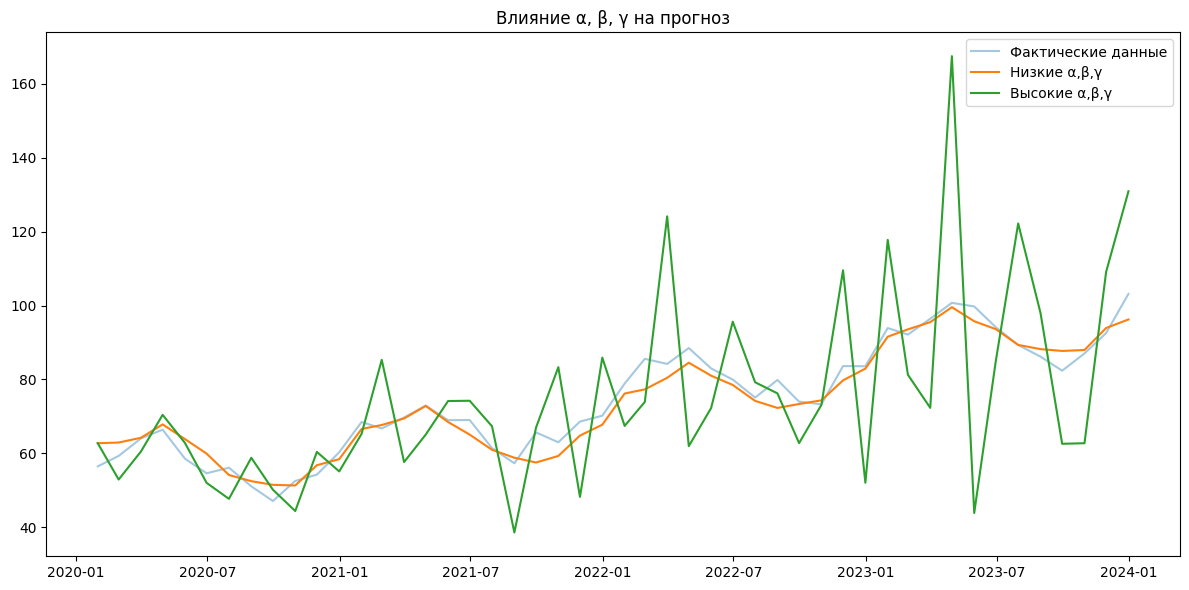

In [40]:
# Модели с разными параметрами
models = {
	"Низкие α,β,γ": ExponentialSmoothing(df["sales"], trend="add", seasonal="add", seasonal_periods=12).fit(
    	smoothing_level=0.1, smoothing_trend=0.1, smoothing_seasonal=0.1, optimized=False),
	"Высокие α,β,γ": ExponentialSmoothing(df["sales"], trend="add", seasonal="add", seasonal_periods=12).fit(
    	smoothing_level=0.9, smoothing_trend=0.9, smoothing_seasonal=0.9, optimized=False)
}
 
plt.figure(figsize=(12,6))
plt.plot(df.index, df["sales"], label="Фактические данные", alpha=0.4)
 
for label, model in models.items():
    plt.plot(model.fittedvalues, label=label)
 
plt.legend()
plt.title("Влияние α, β, γ на прогноз")
plt.tight_layout()
plt.show()